# 9.5 Implementing KNN using Python

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn

## Importing (Reading) Datasets

In [2]:
data = pd.read_csv('../Data/breast_cancer_master.csv')
print(data.shape)
data.head()

(569, 32)


,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Checking for any null values in dataset

In [3]:
data.isnull().sum()

id                         0
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64

## Assigning dependent and independent variables

In [4]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

## Splitting the dataset into Training and Testing Dataset

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

## Preprocessing Data with StandardScaler

In [6]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Training the Model using KNN (minkowski)

In [7]:
results = []
for i in [1, 2, 3, 4, 5]:
    model = KNeighborsClassifier(n_neighbors=i, metric='minkowski', p=2)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    Accuracy_score = metrics.accuracy_score(y_test, y_pred)
    results.append(Accuracy_score)
    
    if i == 5:
        print('KNN [ minkowski ]')
        print(f'for n_neighbor={i} :')
        conf_mat = metrics.confusion_matrix(y_test, y_pred)
        print('\nConfusion Matrix : ', conf_mat)
        print('Accuracy Score : ', Accuracy_score)
        print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')
        print('\n', classification_report(y_pred, y_test))

print(results)

KNN [ minkowski ]
for n_neighbor=5 :

Confusion Matrix :  [[107   1]
 [  6  57]]
Accuracy Score :  0.9590643274853801
Accuracy in Percentage :  95 %

               precision    recall  f1-score   support

           B       0.99      0.95      0.97       113
           M       0.90      0.98      0.94        58

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171

[0.9298245614035088, 0.935672514619883, 0.935672514619883, 0.9473684210526315, 0.9590643274853801]


## Confusion Matrix Heatmap

[Text(0.5, 1.0, 'KNN [ minkowski, neighbor=5 ]')]

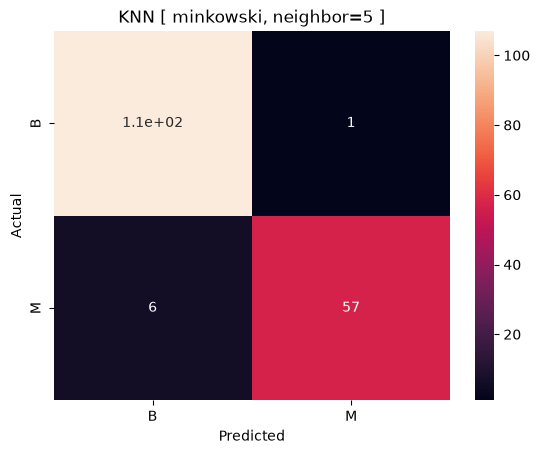

In [8]:
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title='KNN [ minkowski, neighbor=5 ]')

## Model Comparison

In [9]:
models = pd.DataFrame({
    'n_neighbors': ['1', '2', '3', '4', '5'],
    'Accuracy Score': [results[0], results[1], results[2], results[3], results[4]]
})
models = models.sort_values(by='Accuracy Score', ascending=False)
print(models.to_string(index=False))

n_neighbors  Accuracy Score
          5        0.959064
          4        0.947368
          3        0.935673
          2        0.935673
          1        0.929825
